# Math 9 Final Project

Atticus Wong, Ambareesh Lankipalli

### 1. Introduction and Guiding Questions

For our final project, we decided to analyze a dataset on student dropout and academic success. We chose this because we were curious on what factors would contribute the most to the success/failure of a student, which could then benefit more future decisions in our lives.

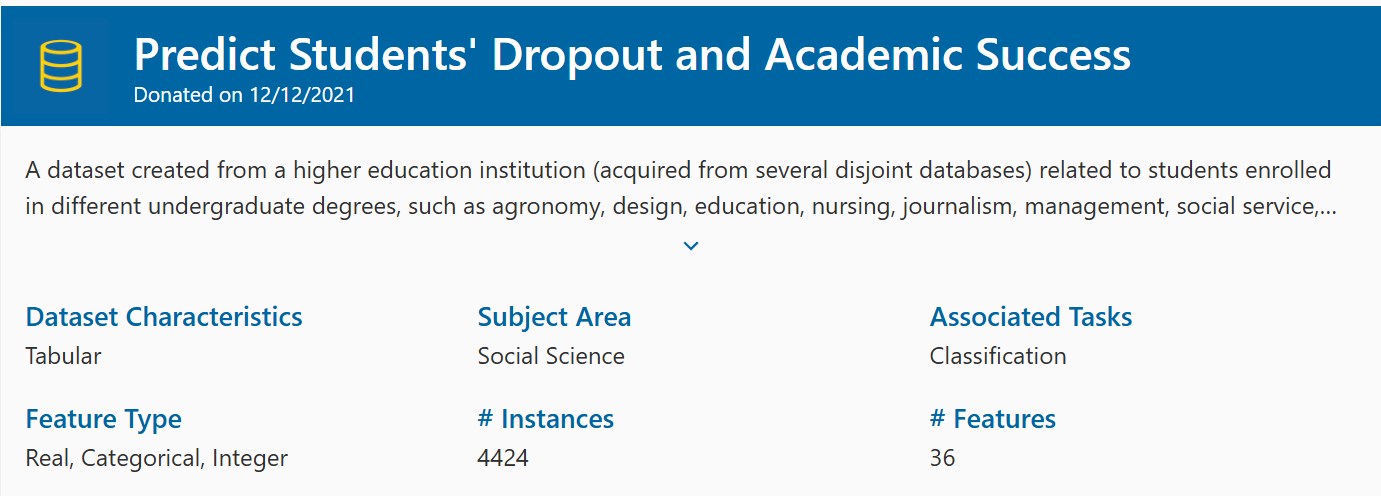

Our guiding questions are as follows:

1. What factors (that a student can/can't control) contribute the most to a student's academic outcomes?
- Since this may be too broad, I decided to follow up with some simpler questions
    - Are students with scholarships more likely to graduate than students without scholarships
    - How predictive are 1st-semester metrics of final outcome?
    - Do parents' previous qualifications affect dropout rate?

2. Can previous qualification factors predict performance?

3. What subgroup of students are the most likely to drop out?

4. TBD

Editor note: I didn't follow the question from the README.md. If you want, you can reorder them.

## Data Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv", delimiter=";")
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Important Columns:
- Curricular units 1st sem (grade): the grade of a student after 1st semester
- Curricular units 2nd sem (grade): the grade of a student after 2nd semester
- Target: Classification task at the end of the normal duration of a course

These columns will be important because with these, we can quantitavely and categorically measure a student's academic performance, and compare them against other columns in order to determine which factors have the greatest effect on a student's academic success.

Because this dataset displays its rows numerically rather than categorically, making it difficult to read, we convert back to categorical values with the categories given in the [website](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success), along with using a comma as a delimiter instead of a semicolon. The code for doing so can be found in `scripts/convert_to_category.ipynb`.

In [3]:
df = pd.read_csv("student_data_categorized.csv")
df.head(5)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Unemployment rate,Inflation rate,GDP,Target
0,Single,17,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,15,1,Tourism,Daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1,5,Communication Design,Daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,17,2,Journalism and Communication,Daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,39,1,Social Service (evening attendance),Evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Data Manipulation

In [4]:
df = pd.read_csv("student_data_categorized.csv")

### 3.1 Data Manipulation for Previous Qualifications

In [21]:
# check to see that grade = 0 and approved = 0 overla[]
sem1_grade_zero = df['1st_sem_grade'] == 0
sem1_enrolled_zero = df['1st_sem_approved'] == 0

sem2_grade_zero = df['2nd_sem_grade'] == 0
sem2_enrolled_zero = df['2nd_sem_approved'] == 0

both_zero_sem1 = sem1_grade_zero & sem1_enrolled_zero
print("Sem 1 grade == 0 and enrolled == 0 count:", both_zero_sem1.sum())
print("enrolled == 0 count:", sem1_grade_zero.sum(), "\n")

# both grade and enrolled are 0 in semester 2
both_zero_sem2 = sem2_grade_zero & sem2_enrolled_zero
print("Sem 2 grade == 0 and enrolled == 0 count:", both_zero_sem2.sum())
print("enrolled == 0 count:", sem2_grade_zero.sum(), "\n")

# inactive for both semesters
fully_inactive = both_zero_sem1 & both_zero_sem2
print(f"Rows fully inactive (both semesters):", fully_inactive.sum())

Sem 1 grade == 0 and enrolled == 0 count: 718
enrolled == 0 count: 718 

Sem 2 grade == 0 and enrolled == 0 count: 870
enrolled == 0 count: 870 

Rows fully inactive (both semesters): 676


In order to properly create a column that stored the grade differences between semesters, we removed rows where the grade of a student was 0. A grade of 0 (as confirmed above) student was inactive for that semseter, and as such, could not be used to determine their performance trend.

In [ ]:
df_prev = df.drop(columns=["Marital status", "Application mode", "Daytime/evening attendance", "Nationality"])

# Getting rid of the rows where grades = 0
df_prev_filtered = df_prev[(df_prev['1st_sem_grade'] != 0) | (df_prev['2nd_sem_grade'] != 0)]

# create column for grade difference (2nd - 1st sem)
df_prev_filtered["grade_diff"] = df_prev_filtered["2nd_sem_grade"] - df_prev_filtered["1st_sem_grade"]
df_prev_filtered["grade_diff"] = df_prev_filtered["2nd_sem_approved"] - df_prev_filtered["1st_sem_approved"]

# column for credits completed / credits enrolled
df_prev_filtered["%_credits_completed_1st_sem"] = np.where(
    df_prev_filtered["1st_sem_enrolled"] != 0,
    df_prev_filtered["1st_sem_credited"] / df_prev_filtered["1st_sem_enrolled"],
    0
)

df_prev_filtered["%_credits_completed_2nd_sem"] = np.where(
    df_prev_filtered["2nd_sem_enrolled"] != 0,
    df_prev_filtered["2nd_sem_credited"] / df_prev_filtered["2nd_sem_enrolled"],
    0
)

df_prev_filtered["%_credits_completed_diff"] = df_prev_filtered["%_credits_completed_2nd_sem"] - df_prev_filtered["%_credits_completed_1st_sem"]
df_prev_filtered.head()

,Application order,Course,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,...,2nd_sem_grade,2nd_sem_without_eval,Unemployment rate,Inflation rate,GDP,Target,grade_diff,%_credits_completed_1st_sem,%_credits_completed_2nd_sem,%_credits_completed_diff
1,1,Tourism,Secondary education,160.0,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,Intermediate Level Technicians and Professions,Intermediate Level Technicians and Professions,142.5,1,...,13.666667,0,13.9,-0.3,0.79,Graduate,0,0.0,0.0,0.0
3,2,Journalism and Communication,Secondary education,122.0,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,"Personal Services, Security and Safety Workers...",Intermediate Level Technicians and Professions,119.6,1,...,12.400000,0,9.4,-0.8,-3.12,Graduate,-1,0.0,0.0,0.0
4,1,Social Service (evening attendance),Secondary education,100.0,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Unskilled Workers,Unskilled Workers,141.5,0,...,13.000000,0,13.9,-0.3,0.79,Graduate,1,0.0,0.0,0.0
5,1,Management (evening attendance),Basic education 3rd cycle (9th/10th/11th year)...,133.1,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,Unskilled Workers,"Skilled Workers in Industry, Construction and ...",114.8,0,...,11.500000,5,16.2,0.3,-0.92,Graduate,0,0.0,0.0,0.0
6,1,Nursing,Secondary education,142.0,Basic Education 3rd Cycle (9th/10th/11th Year)...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,"Skilled Workers in Industry, Construction and ...",Armed Forces Professions,128.4,1,...,14.345000,0,15.5,2.8,-4.06,Graduate,1,0.0,0.0,0.0


## 4. Visualizations

### 4.1 Visualizations for Previous Qualifications

C:\Users\attic\AppData\Local\Temp\ipykernel_17132\684736136.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


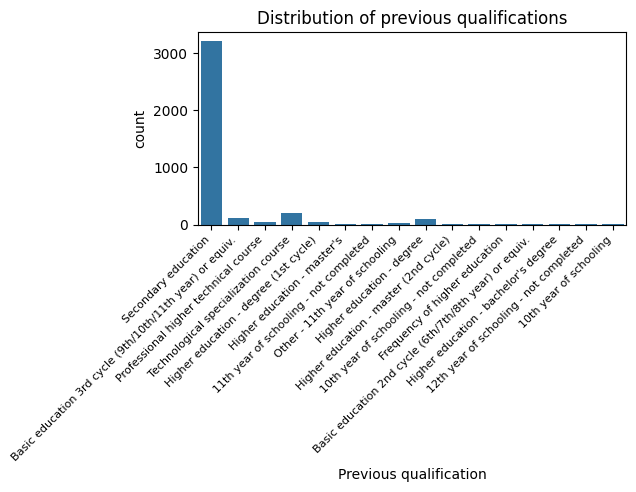

In [6]:
ax = sns.countplot(x='Previous qualification', data=df_prev_filtered)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.title("Distribution of previous qualifications")
plt.show()

# Looks like the majority of students had mostly secondary education

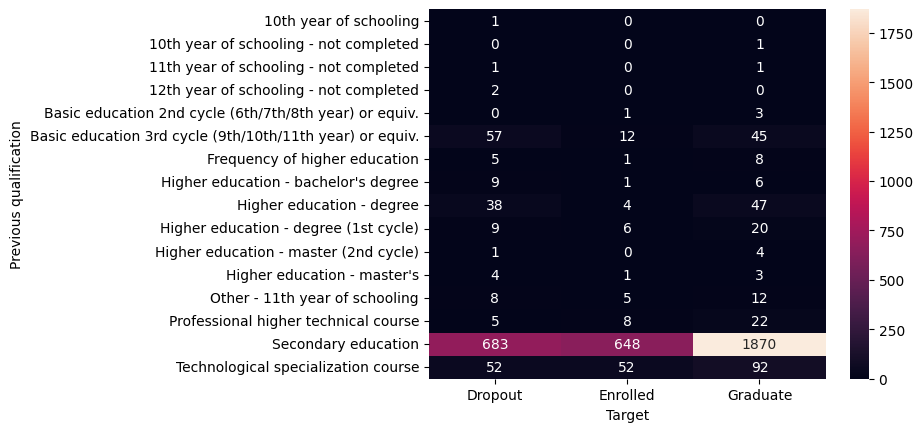

In [7]:
# Comparing previous qualification category against Target column
ct = pd.crosstab(df_prev_filtered['Previous qualification'], df_prev_filtered['Target'])

sns.heatmap(ct, annot=True, fmt='d')
plt.xlabel('Target')
plt.ylabel('Previous qualification')
plt.show()

As seen from this heatmap, graduating from high school would have the highest graduation rate, so coming into college with a high school degree is highly associated with graduation.

On the other hand, students coming from Basic education (9th/10th/11th) has a higher proportion of students that dropped out at the end of the school year instead of graduating, outnumbering the number of graduates.

Some other higlights are students coming from  "Higher education - degree", where a decent amount of students dropped out before graduation. This could imply that the student no longer needed the degree, since they already had one.

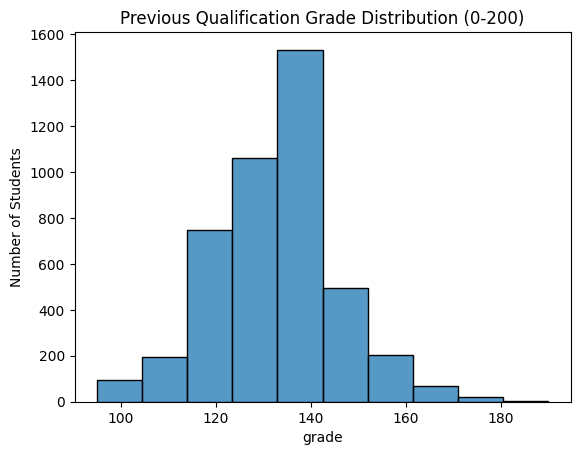

In [8]:
# Plotting Grade Distribution
sns.histplot(df_prev['Previous qualification (grade)'], bins=10)
plt.xlabel("grade")
plt.ylabel("Number of Students")
plt.title("Previous Qualification Grade Distribution (0-200)")
plt.show()

C:\Users\attic\AppData\Local\Temp\ipykernel_17132\1751115665.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Previous qualification (grade)', data=df_prev_filtered, ax=axes[0],
C:\Users\attic\AppData\Local\Temp\ipykernel_17132\1751115665.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='grade_diff', data=df_prev_filtered, ax=axes[1],


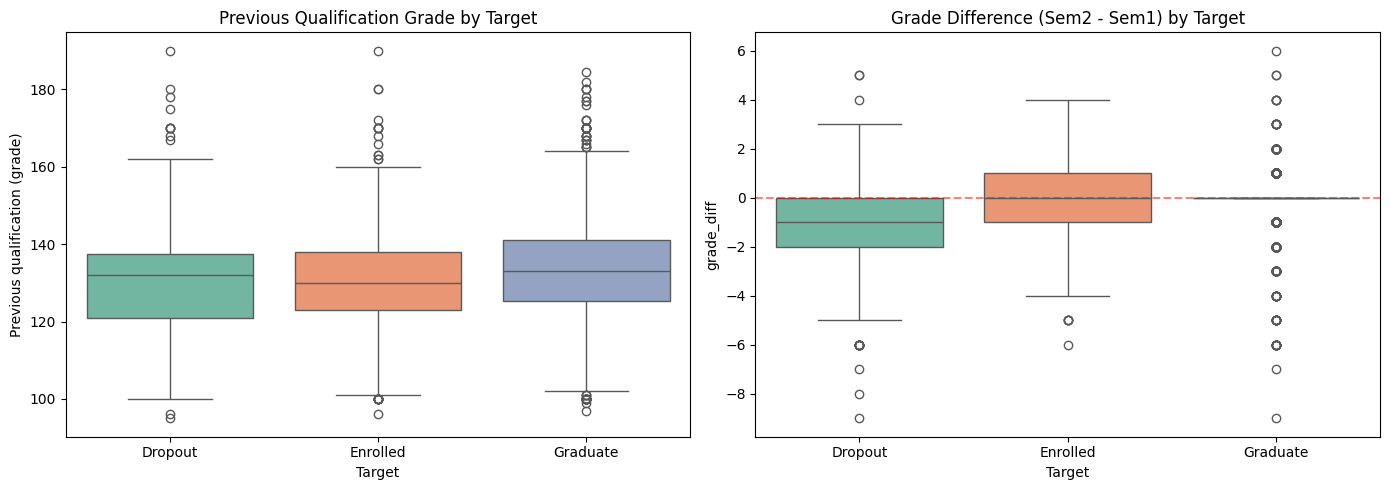

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Target', y='Previous qualification (grade)', data=df_prev_filtered, ax=axes[0],
            order=['Dropout', 'Enrolled', 'Graduate'], palette='Set2')
axes[0].set_title('Previous Qualification Grade by Target')

sns.boxplot(x='Target', y='grade_diff', data=df_prev_filtered, ax=axes[1],
            order=['Dropout', 'Enrolled', 'Graduate'], palette='Set2')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Grade Difference (Sem2 - Sem1) by Target')

plt.tight_layout()
plt.show()

Looking at the box plots, it seems to show that the grades of a student's previous qualifications do not affect their academic performance in college. The three box plots are nearly indisguishable, aside from a tiny difference from the Graduate targers. 

Because of this, it's safe to say that previous qualification grades don't have a large effect on a student's academic performance in the future. It's not a very good predictor for academic performance.

However for grade differences between 1st and 2nd semester, the "Graduate" box plot is more distinguishable than the dropout plot, as it has a greater median and centers more around a consistent grade difference. The median for the dropout group is negative, with many outliers sitting well in the negatives. 
For the enrolled group, it's the difference is more stable.
For the graduate group, median is essentially 0, with an extremely tight IQR clustered right at zero. This means that the majority of grade differences for the graduate group have no change. In addition, there are also outliers on both sides.

**What this means:**

Grade differences between 1st and 2nd semester are fairly strong predictors for academic performance. 
- If a student has a worse performance between 1st and 2nd semester, they tend to be more likely to drop out. 
- If a student has consistent performance or improves between semesters, they tend to be graduates.
- If a student is in the middle, they would tend to be in the target Enrolled.

**Notes:**

Even though we stated that a graduate would have better academic performance, there were outliers in the negatives, similar to the dropout group. This implies grade differences shouldn't be the sole predictor of academic performance, and that there should be other factors to consider before making a final prediction.

## 5. Numerical Summaries

In [10]:
df_prev_filtered.groupby('Target')['grade_diff'].describe()

df_copy = df_prev_filtered

df_copy.groupby('Target')['grade_diff'].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
Dropout,875.0,-0.993143,1.789225,-9.0,-2.0,-1.0,0.0,5.0
Enrolled,739.0,-0.280108,1.520866,-6.0,-1.0,0.0,1.0,4.0
Graduate,2134.0,-0.057170,1.154096,-9.0,0.0,0.0,0.0,6.0


## 6. Interpretation

## 7. Limitations

## 8. Conclusion